In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn import metrics
import xgboost as xgb
import time
from matplotlib import pyplot as plt

In [6]:
data = pd.read_csv("data.csv")
data

,Time,COURANT ValueY,DEBIT EAU ValueY,SOLIDE ValueY,PUISSANCE ValueY,refus_tamis
0,2022-01-28 00:00:00,67.253113,10.185185,121.003326,576.604736,20.849820
1,2022-01-28 00:01:00,67.253113,10.185185,121.003326,576.604736,20.849820
2,2022-01-28 00:02:00,67.253113,10.185185,121.003326,576.604736,20.849820
3,2022-01-28 00:03:00,67.253113,10.185185,121.003326,576.604736,20.849820
4,2022-01-28 00:04:00,67.253113,10.185185,121.003326,576.604736,20.849820
...,...,...,...,...,...,...
101066,2022-10-20 16:57:00,NaN,NaN,NaN,507.211636,19.755739
101067,2022-10-20 16:58:00,NaN,NaN,NaN,511.160186,19.755739
101068,2022-10-20 16:59:00,NaN,NaN,NaN,509.005283,19.755739
101069,2022-10-20 17:00:00,NaN,NaN,NaN,510.360491,19.755739


In [7]:
data['Time'] = pd.to_datetime(data['Time'], format="%Y/%m/%d %H:%M:%S")
data.dtypes

Time                datetime64[ns]
COURANT ValueY             float64
DEBIT EAU ValueY           float64
SOLIDE ValueY              float64
PUISSANCE ValueY           float64
refus_tamis                float64
dtype: object

In [8]:
dep_test = data.sample(100)
dep_test

,Time,COURANT ValueY,DEBIT EAU ValueY,SOLIDE ValueY,PUISSANCE ValueY,refus_tamis
38925,2022-09-07 02:43:00,70.169877,11.865643,113.460344,605.569188,19.040950
92485,2022-10-14 17:56:00,59.958714,9.168355,110.568576,513.796298,17.764125
99024,2022-10-19 06:55:00,60.093289,9.027898,109.833442,512.047810,19.743049
44429,2022-09-10 22:27:00,65.239209,11.797388,112.025545,558.804438,17.820320
10365,2022-02-04 04:45:00,66.177883,9.648317,NaN,566.984910,25.668804
...,...,...,...,...,...,...
20341,2022-08-25 04:59:00,68.046064,13.488346,114.699132,583.567351,20.218690
46615,2022-09-12 10:53:00,0.000000,0.000000,0.000000,0.000000,21.136453
22634,2022-08-26 19:12:00,68.650797,13.929725,137.886365,589.257937,20.767765
17450,2022-02-17 06:03:00,67.681134,9.523993,108.832466,572.853273,18.026565


In [9]:
data.drop(dep_test.index, inplace=True)
data.shape

(100971, 6)

In [10]:
X = data[["Time","COURANT ValueY","DEBIT EAU ValueY","SOLIDE ValueY","refus_tamis"]]
X

,Time,COURANT ValueY,DEBIT EAU ValueY,SOLIDE ValueY,refus_tamis
0,2022-01-28 00:00:00,67.253113,10.185185,121.003326,20.849820
1,2022-01-28 00:01:00,67.253113,10.185185,121.003326,20.849820
2,2022-01-28 00:02:00,67.253113,10.185185,121.003326,20.849820
3,2022-01-28 00:03:00,67.253113,10.185185,121.003326,20.849820
4,2022-01-28 00:04:00,67.253113,10.185185,121.003326,20.849820
...,...,...,...,...,...
101066,2022-10-20 16:57:00,NaN,NaN,NaN,19.755739
101067,2022-10-20 16:58:00,NaN,NaN,NaN,19.755739
101068,2022-10-20 16:59:00,NaN,NaN,NaN,19.755739
101069,2022-10-20 17:00:00,NaN,NaN,NaN,19.755739


In [11]:
y = data[["Time","PUISSANCE ValueY"]]
y

,Time,PUISSANCE ValueY
0,2022-01-28 00:00:00,576.604736
1,2022-01-28 00:01:00,576.604736
2,2022-01-28 00:02:00,576.604736
3,2022-01-28 00:03:00,576.604736
4,2022-01-28 00:04:00,576.604736
...,...,...
101066,2022-10-20 16:57:00,507.211636
101067,2022-10-20 16:58:00,511.160186
101068,2022-10-20 16:59:00,509.005283
101069,2022-10-20 17:00:00,510.360491


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [13]:
X_train_1 = X_train[["DEBIT EAU ValueY","SOLIDE ValueY","refus_tamis"]]
X_test_1 = X_test[["DEBIT EAU ValueY","SOLIDE ValueY","refus_tamis"]]
y_train_1 = y_train[["PUISSANCE ValueY"]]
y_test_1 = y_test[["PUISSANCE ValueY"]]

In [14]:
imputer = SimpleImputer(missing_values=np.nan, strategy="mean")
X_train_1 = pd.DataFrame(imputer.fit_transform(X_train_1), columns=["DEBIT EAU ValueY","SOLIDE ValueY","refus_tamis"],index=X_train_1.index)
X_train_1

,DEBIT EAU ValueY,SOLIDE ValueY,refus_tamis
16200,9.935153,115.748616,19.930912
69484,11.333609,141.974921,18.198089
86720,9.763525,114.297774,20.874999
97483,10.864318,110.003134,21.997273
14212,9.563079,117.946757,22.158927
...,...,...,...
6275,8.986304,108.930122,27.598417
54947,10.931666,115.707489,21.232549
76899,8.145255,98.071288,18.734397
861,10.323471,119.338047,20.849820


In [15]:
X_test_1 = pd.DataFrame(imputer.transform(X_test_1), columns=["DEBIT EAU ValueY","SOLIDE ValueY","refus_tamis"],index=X_test_1.index)
X_test_1

,DEBIT EAU ValueY,SOLIDE ValueY,refus_tamis
20659,13.143691,0.000000,20.218690
67095,11.590992,119.016367,20.732685
75919,2.295447,0.000000,18.734397
34003,0.000000,0.000000,22.282692
29168,9.268126,109.778985,18.017168
...,...,...,...
28750,9.683020,110.376064,18.017168
100866,10.144917,108.757716,19.755739
81087,9.697487,109.575972,16.236483
18627,12.279136,113.432343,17.766038


In [16]:
dep_test_X = dep_test[["DEBIT EAU ValueY","SOLIDE ValueY","refus_tamis"]]
dep_test_Y = dep_test[["PUISSANCE ValueY"]]

In [17]:
dep_test_X = pd.DataFrame(imputer.transform(dep_test_X), columns=["DEBIT EAU ValueY","SOLIDE ValueY","refus_tamis"],index=dep_test_X.index)
dep_test_X

,DEBIT EAU ValueY,SOLIDE ValueY,refus_tamis
38925,11.865643,113.460344,19.040950
92485,9.168355,110.568576,17.764125
99024,9.027898,109.833442,19.743049
44429,11.797388,112.025545,17.820320
10365,9.648317,106.667840,25.668804
...,...,...,...
20341,13.488346,114.699132,20.218690
46615,0.000000,0.000000,21.136453
22634,13.929725,137.886365,20.767765
17450,9.523993,108.832466,18.026565


Linear Regression

In [18]:
lin_reg = LinearRegression()
Start_Time = time.time()
lin_reg.fit(X_train_1, y_train_1)
Execution_Time_lin_reg = time.time() - Start_Time
print(f"Train : {lin_reg.score(X_train_1, y_train_1)}")
print(f"Test : {lin_reg.score(X_test_1, y_test_1)}")

Train : 0.7972387458641452
Test : 0.8078682790505246


Polynomial Regression

In [19]:
poly_reg = PolynomialFeatures(degree=4)
X_poly = poly_reg.fit_transform(X_train_1)
pol_reg = LinearRegression()

Start_Time = time.time()
pol_reg.fit(X_poly, y_train_1)
Execution_Time_poly_reg = time.time() - Start_Time
print(f"Train : {pol_reg.score(X_poly, y_train_1)}")
X_test_poly = poly_reg.transform(X_test_1)
print(f"Test : {pol_reg.score(X_test_poly, y_test_1)}")

Train : 0.9215902127392896
Test : 0.9250682379678128


KNN

In [20]:
Start_Time = time.time()
knn_model = KNeighborsRegressor(n_neighbors=5).fit(X_train_1, y_train_1)
Execution_Time_knn = time.time() - Start_Time
print(f"Train : {knn_model.score(X_train_1, y_train_1)}")
print(f"Test : {knn_model.score(X_test_1, y_test_1)}")

Train : 0.9724478800448022
Test : 0.9593121322892644


XGBoost

In [21]:
model = xgb.XGBRegressor()
Start_Time = time.time()
model.fit(X_train_1, y_train_1)
Execution_Time_xgboost = time.time() - Start_Time
print(f"Train : {model.score(X_train_1, y_train_1)}")
print(f"Test : {model.score(X_test_1, y_test_1)}")

Train : 0.9891863233383937
Test : 0.9722697382511803


Prediction for the test

In [22]:
Start_time = time.time()
y_predict_dep_test_lin_reg = lin_reg.predict(X_test_1)
lin_reg_pred_time = time.time() - Start_time
##############################################################
Start_time = time.time()
y_predict_dep_test_poly_reg = pol_reg.predict(poly_reg.transform(X_test_1))
poly_reg_pred_time = time.time() - Start_time
##############################################################
Start_time = time.time()
y_predict_dep_test_knn = knn_model.predict(X_test_1)
knn_pred_time = time.time() - Start_time
##############################################################
Start_time = time.time()
y_predict_dep_test_xgboost = model.predict(X_test_1)
xgboost_pred_time = time.time() - Start_time

In [23]:
pd.DataFrame({'MSE':[metrics.mean_squared_error(y_test_1,lin_reg.predict(X_test_1)),metrics.mean_squared_error(y_test_1,pol_reg.predict(poly_reg.transform(X_test_1))),metrics.mean_squared_error(y_test_1,knn_model.predict(X_test_1)),metrics.mean_squared_error(y_test_1,model.predict(X_test_1))],
              'MAE': [metrics.mean_absolute_error(y_test_1,lin_reg.predict(X_test_1)),metrics.mean_absolute_error(y_test_1,pol_reg.predict(poly_reg.transform(X_test_1))),metrics.mean_absolute_error(y_test_1,knn_model.predict(X_test_1)),metrics.mean_absolute_error(y_test_1,model.predict(X_test_1))],
              'R2':[lin_reg.score(X_test_1, y_test_1),pol_reg.score(poly_reg.transform(X_test_1), y_test_1),knn_model.score(X_test_1, y_test_1),model.score(X_test_1, y_test_1)],
              'Time of Execution train (s)':[Execution_Time_lin_reg,Execution_Time_poly_reg,Execution_Time_knn,Execution_Time_xgboost],
              'Time of prediction test (s)':[lin_reg_pred_time,poly_reg_pred_time,knn_pred_time,xgboost_pred_time]}, index=["LinearRegression","PolynomialRegression","KNN","XGBoost"])

,MSE,MAE,R2,Time of Execution train (s),Time of prediction test (s)
LinearRegression,4106.966859,41.676846,0.807868,0.029591,0.005810
PolynomialRegression,1601.725430,22.773496,0.925068,0.147960,0.018609
KNN,869.735218,11.355845,0.959312,0.195224,0.236366
XGBoost,592.756185,8.357859,0.972270,2.765373,0.055389


Evaluate the model with dep_test sample and plot the result

In [24]:
y_predict_dep_test_lin_reg = lin_reg.predict(dep_test_X)
y_predict_dep_test_poly_reg = pol_reg.predict(poly_reg.transform(dep_test_X))
y_predict_dep_test_knn = knn_model.predict(dep_test_X)
y_predict_dep_test_xgboost = model.predict(dep_test_X)

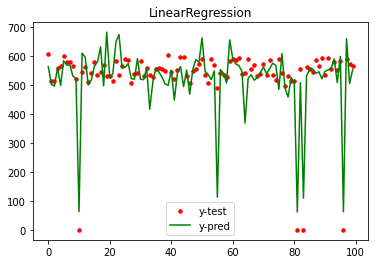

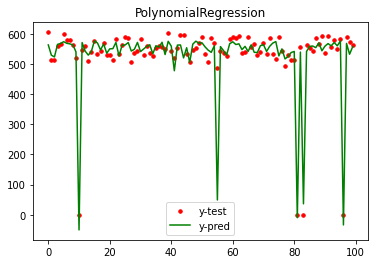

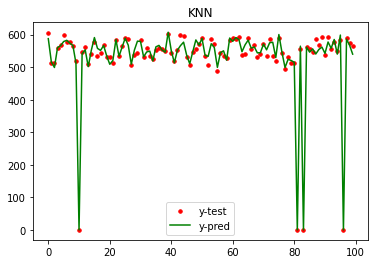

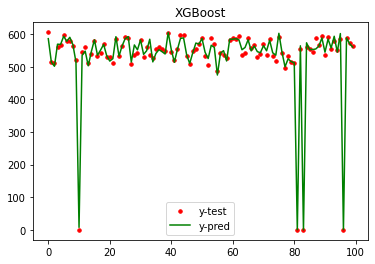

In [25]:
list_prediction = [y_predict_dep_test_lin_reg,y_predict_dep_test_poly_reg,y_predict_dep_test_knn,y_predict_dep_test_xgboost]
list_alg = ["LinearRegression","PolynomialRegression","KNN","XGBoost"]
for pred,alg in zip(list_prediction,list_alg):
    x_ax = range(len(dep_test_X))
    plt.scatter(x_ax, dep_test_Y,  s=12, label="y-test",c= "red")
    plt.plot(x_ax, pred, label="y-pred",c = "green")
    plt.legend()
    plt.title(alg)
    plt.show()

without refus_tamis

Linear Regression

In [32]:
lin_reg_without_rf_tamis = LinearRegression()
Start_Time = time.time()
lin_reg_without_rf_tamis.fit(X_train_1[["DEBIT EAU ValueY","SOLIDE ValueY"]], y_train_1)
Execution_Time_lin_reg = time.time() - Start_Time
print(f"Train : {lin_reg_without_rf_tamis.score(X_train_1[['DEBIT EAU ValueY','SOLIDE ValueY']], y_train_1)}")
print(f"Test : {lin_reg_without_rf_tamis.score(X_test_1[['DEBIT EAU ValueY','SOLIDE ValueY']], y_test_1)}")

Train : 0.797125301031512
Test : 0.8078828580840473


Polynomial Regression

In [34]:
poly_reg_without_rf_tamis = PolynomialFeatures(degree=4)
X_poly_without_rf_tamis = poly_reg_without_rf_tamis.fit_transform(X_train_1[["DEBIT EAU ValueY","SOLIDE ValueY"]])
pol_reg_without_rf_tamis = LinearRegression()

Start_Time = time.time()
pol_reg_without_rf_tamis.fit(X_poly_without_rf_tamis, y_train_1)
Execution_Time_poly_reg = time.time() - Start_Time
print(f"Train : {pol_reg_without_rf_tamis.score(X_poly_without_rf_tamis, y_train_1)}")
X_test_poly = poly_reg_without_rf_tamis.transform(X_test_1[["DEBIT EAU ValueY","SOLIDE ValueY"]])
print(f"Test : {pol_reg_without_rf_tamis.score(X_test_poly, y_test_1)}")

Train : 0.9140099917379648
Test : 0.917146446031491


KNN

In [28]:
Start_Time = time.time()
knn_model_withou_rf_tamis = KNeighborsRegressor(n_neighbors=5).fit(X_train_1[["DEBIT EAU ValueY","SOLIDE ValueY"]], y_train_1)
Execution_Time_knn = time.time() - Start_Time
print(f'Train : {knn_model_withou_rf_tamis.score(X_train_1[["DEBIT EAU ValueY","SOLIDE ValueY"]], y_train_1)}')
print(f'Test : {knn_model_withou_rf_tamis.score(X_test_1[["DEBIT EAU ValueY","SOLIDE ValueY"]], y_test_1)}')

Train : 0.9533872712417755
Test : 0.931208561041267


XGBoost

In [29]:
model_without_rf_tamis = xgb.XGBRegressor()
Start_Time = time.time()
model_without_rf_tamis.fit(X_train_1[["DEBIT EAU ValueY","SOLIDE ValueY"]], y_train_1)
Execution_Time_xgboost = time.time() - Start_Time
print(f'Train : {model_without_rf_tamis.score(X_train_1[["DEBIT EAU ValueY","SOLIDE ValueY"]], y_train_1)}')
print(f'Test : {model_without_rf_tamis.score(X_test_1[["DEBIT EAU ValueY","SOLIDE ValueY"]], y_test_1)}')

Train : 0.9627212864270158
Test : 0.9354458302140972


Prediction for the test

In [30]:
Start_time = time.time()
y_predict_dep_test_lin_reg = lin_reg_without_rf_tamis.predict(X_test_1[["DEBIT EAU ValueY","SOLIDE ValueY"]])
lin_reg_pred_time = time.time() - Start_time
##############################################################
Start_time = time.time()
y_predict_dep_test_poly_reg = pol_reg_without_rf_tamis.predict(poly_reg_without_rf_tamis.transform(X_test_1[["DEBIT EAU ValueY","SOLIDE ValueY"]]))
poly_reg_pred_time = time.time() - Start_time
##############################################################
Start_time = time.time()
y_predict_dep_test_knn = knn_model_withou_rf_tamis.predict(X_test_1[["DEBIT EAU ValueY","SOLIDE ValueY"]])
knn_pred_time = time.time() - Start_time
##############################################################
Start_time = time.time()
y_predict_dep_test_xgboost = model_without_rf_tamis.predict(X_test_1[["DEBIT EAU ValueY","SOLIDE ValueY"]])
xgboost_pred_time = time.time() - Start_time

In [35]:
pd.DataFrame({'MSE':[metrics.mean_squared_error(y_test_1,lin_reg_without_rf_tamis.predict(X_test_1[["DEBIT EAU ValueY","SOLIDE ValueY"]])),metrics.mean_squared_error(y_test_1,pol_reg_without_rf_tamis.predict(poly_reg_without_rf_tamis.transform(X_test_1[["DEBIT EAU ValueY","SOLIDE ValueY"]]))),metrics.mean_squared_error(y_test_1,knn_model_withou_rf_tamis.predict(X_test_1[["DEBIT EAU ValueY","SOLIDE ValueY"]])),metrics.mean_squared_error(y_test_1,model_without_rf_tamis.predict(X_test_1[["DEBIT EAU ValueY","SOLIDE ValueY"]]))],
              'MAE': [metrics.mean_absolute_error(y_test_1,lin_reg_without_rf_tamis.predict(X_test_1[["DEBIT EAU ValueY","SOLIDE ValueY"]])),metrics.mean_absolute_error(y_test_1,pol_reg_without_rf_tamis.predict(poly_reg_without_rf_tamis.transform(X_test_1[["DEBIT EAU ValueY","SOLIDE ValueY"]]))),metrics.mean_absolute_error(y_test_1,knn_model_withou_rf_tamis.predict(X_test_1[["DEBIT EAU ValueY","SOLIDE ValueY"]])),metrics.mean_absolute_error(y_test_1,model_without_rf_tamis.predict(X_test_1[["DEBIT EAU ValueY","SOLIDE ValueY"]]))],
              'R2':[lin_reg_without_rf_tamis.score(X_test_1[["DEBIT EAU ValueY","SOLIDE ValueY"]], y_test_1),pol_reg_without_rf_tamis.score(poly_reg_without_rf_tamis.transform(X_test_1[["DEBIT EAU ValueY","SOLIDE ValueY"]]), y_test_1),knn_model_withou_rf_tamis.score(X_test_1[["DEBIT EAU ValueY","SOLIDE ValueY"]], y_test_1),model_without_rf_tamis.score(X_test_1[["DEBIT EAU ValueY","SOLIDE ValueY"]], y_test_1)],
              'Time of Execution train (s)':[Execution_Time_lin_reg,Execution_Time_poly_reg,Execution_Time_knn,Execution_Time_xgboost],
              'Time of prediction test (s)':[lin_reg_pred_time,poly_reg_pred_time,knn_pred_time,xgboost_pred_time]}, index=["LinearRegression","PolynomialRegression","KNN","XGBoost"])

,MSE,MAE,R2,Time of Execution train (s),Time of prediction test (s)
LinearRegression,4106.655221,41.766480,0.807883,0.012559,0.000000
PolynomialRegression,1771.059972,24.702171,0.917146,0.040077,0.012430
KNN,1470.471188,20.331266,0.931209,0.137564,0.193252
XGBoost,1379.896222,19.209859,0.935446,2.381736,0.049758


Evaluate the model with dep_test sample and plot the result

In [36]:
y_predict_dep_test_lin_reg = lin_reg_without_rf_tamis.predict(dep_test_X[["DEBIT EAU ValueY","SOLIDE ValueY"]])
y_predict_dep_test_poly_reg = pol_reg_without_rf_tamis.predict(poly_reg_without_rf_tamis.transform(dep_test_X[["DEBIT EAU ValueY","SOLIDE ValueY"]]))
y_predict_dep_test_knn = knn_model_withou_rf_tamis.predict(dep_test_X[["DEBIT EAU ValueY","SOLIDE ValueY"]])
y_predict_dep_test_xgboost = model_without_rf_tamis.predict(dep_test_X[["DEBIT EAU ValueY","SOLIDE ValueY"]])

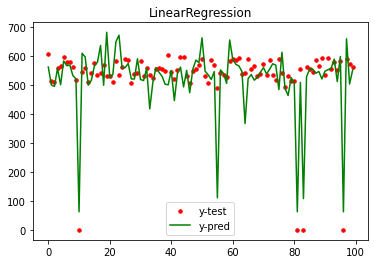

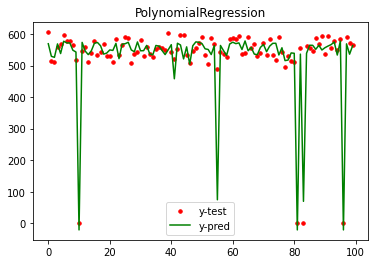

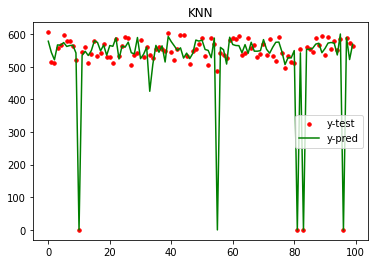

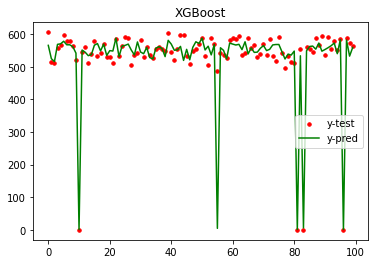

In [37]:
list_prediction = [y_predict_dep_test_lin_reg,y_predict_dep_test_poly_reg,y_predict_dep_test_knn,y_predict_dep_test_xgboost]
list_alg = ["LinearRegression","PolynomialRegression","KNN","XGBoost"]
for pred,alg in zip(list_prediction,list_alg):
    x_ax = range(len(dep_test_X))
    plt.scatter(x_ax, dep_test_Y,  s=12, label="y-test",c= "red")
    plt.plot(x_ax, pred, label="y-pred",c = "green")
    plt.legend()
    plt.title(alg)
    plt.show()

Comparaison Réelle & Prediction pour le deployement sample

In [39]:
prediction = pd.DataFrame(list(zip(dep_test_Y["PUISSANCE ValueY"],knn_model.predict(dep_test_X).T.tolist()[0],model.predict(dep_test_X).T.tolist(),knn_model_withou_rf_tamis.predict(dep_test_X[["DEBIT EAU ValueY","SOLIDE ValueY"]]).T.tolist()[0],model_without_rf_tamis.predict(dep_test_X[["DEBIT EAU ValueY","SOLIDE ValueY"]]).T.tolist())), columns = ['Puissance Réelle','Prediction KNN without courant','Prediction XGBoost without courant','Prediction KNN without courant & rf_tamis','Prediction XGBoost without courant & rf_tamis'])
prediction

,Puissance Réelle,Prediction KNN without courant,Prediction XGBoost without courant,Prediction KNN without courant & rf_tamis,Prediction XGBoost without courant & rf_tamis
0,605.569188,587.392708,585.881775,578.050462,565.378845
1,513.796298,515.478411,513.809631,543.706281,524.543457
2,512.047810,498.802648,501.320770,521.132348,515.660156
3,558.804438,559.883972,568.943787,566.736139,568.479797
4,566.984910,565.876661,568.262634,565.876661,570.054077
...,...,...,...,...,...
95,583.567351,598.434510,601.493286,600.152608,582.980347
96,0.000000,0.000000,0.340340,0.000000,1.251611
97,589.257937,585.943074,588.198669,589.373147,581.788452
98,572.853273,567.121627,570.503906,521.951212,532.459778


In [ ]:
prediction.to_excel("prediction.xlsx")